## **Load and explore the network**

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import cdlib as cdlib
from cdlib import algorithms, evaluation
from cdlib.classes.node_clustering import NodeClustering
import random

# set seed for reproducibility
random.seed(1)
np.random.seed(1)

# load les miserables network
G_les_miserables = nx.les_miserables_graph()

# basic info
print(f"Number of nodes: {G_les_miserables.number_of_nodes()}")
print(f"Number of edges: {G_les_miserables.number_of_edges()}")
print(f"Is directed: {nx.is_directed(G_les_miserables)}")
print(f"Is weighted: {nx.is_weighted(G_les_miserables)}")

# check the weights
print("\nSample of edge weights:")
for u, v, data in list(G_les_miserables.edges(data=True))[:5]:
    print(f" {u} -- {v}: weight = {data['weight']}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.2 MB/s eta 0:00:00
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer', 'leidenalg', 'bayanpy', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'leidenalg', 'infomap', 'wurlitzer'}
Number of nodes: 77
Number of edges: 254
Is directed: False
Is weighted: True

Sample of edge weights:
 Napoleon -- Myriel: weight = 1
 Myriel -- MlleBaptistine: weight = 8
 Myriel -- MmeMagloire: weight = 10
 Myriel -- CountessDeLo: weight = 1
 Myriel -- Geborand: weight = 1


Louvain found 6 communities


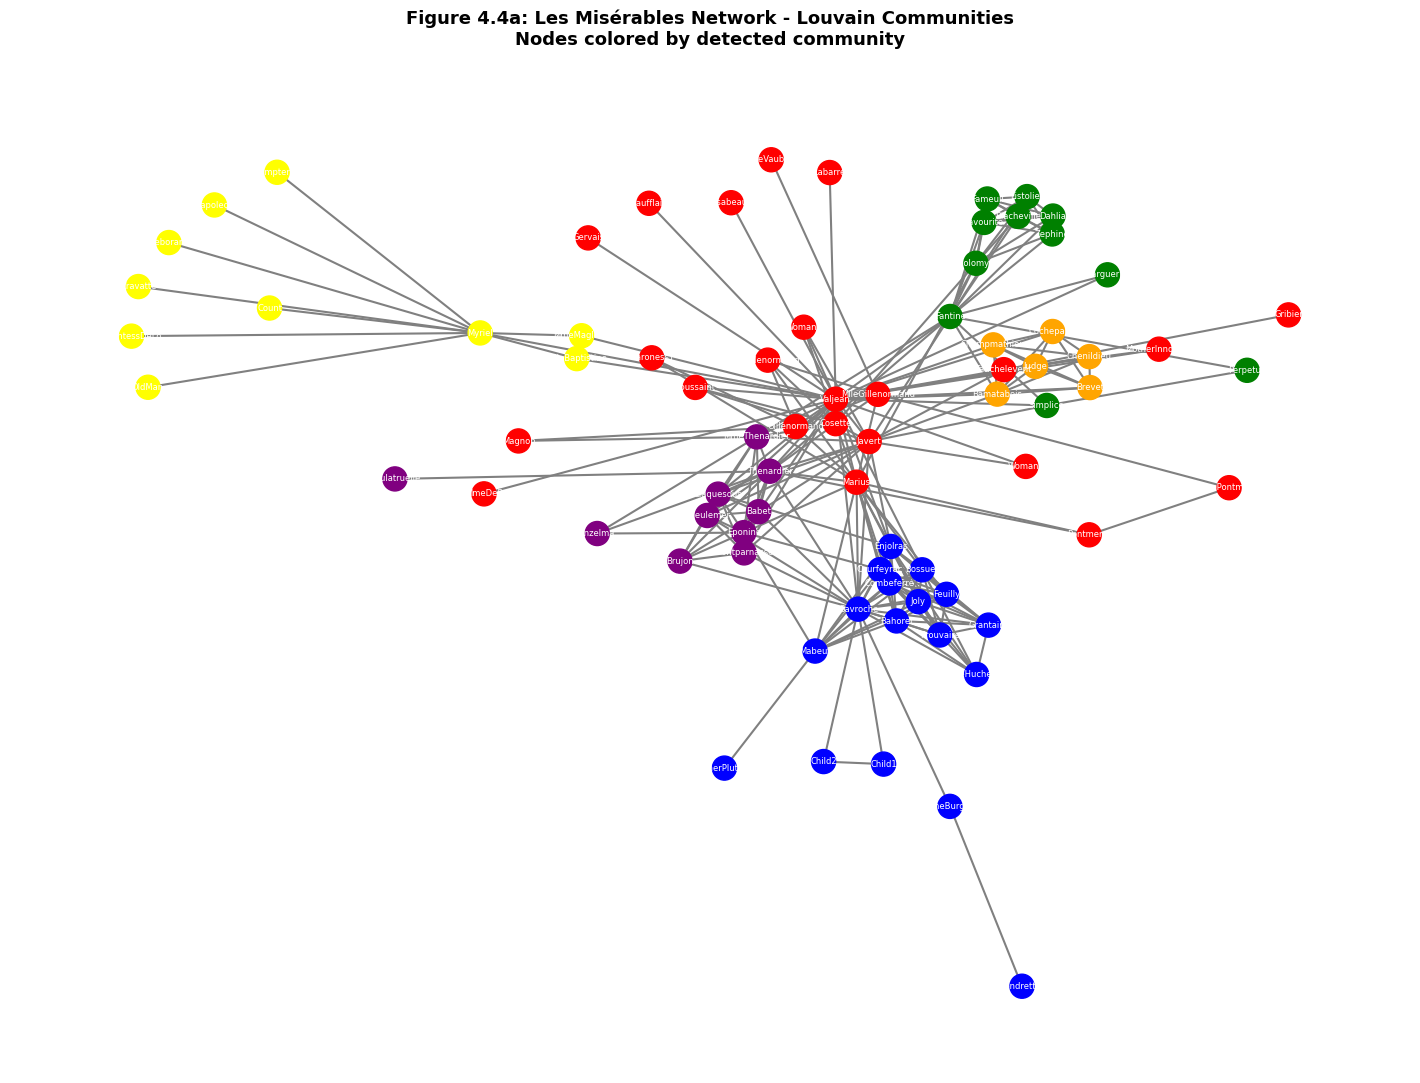

Figure 4.4a saved as 'figure_4_4a_les_miserables_communities.png'


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


# Run Louvain on the weighted graph
louvain_weighted = cdlib.algorithms.louvain(G_les_miserables)
print(f"Louvain found {len(louvain_weighted.communities)} communities")

# Create a mapping of node to community
node_to_community = {}
for community_id, community in enumerate(louvain_weighted.communities):
    for node in community:
        node_to_community[node] = community_id

# Define colors
simple_colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'pink', 'brown', 'gray', 'black']
node_colors = [simple_colors[node_to_community[node]] for node in G_les_miserables.nodes()]

# Layout
pos = nx.spring_layout(G_les_miserables, seed=1)

# Plot
plt.figure(figsize=(14, 10))
nx.draw(G_les_miserables, pos,
        with_labels=True,
        node_color=node_colors,
        node_size=300,
        edge_color="gray",
        width=1.5,
        font_size=6,
        font_color="white")

plt.title("Figure 4.4a: Les Misérables Network - Louvain Communities\nNodes colored by detected community",
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figure_4_4a_les_miserables_communities.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.4a saved as 'figure_4_4a_les_miserables_communities.png'")

## **Experiment — weighted vs unweighted:**

In [ ]:
# doing first without weights
print("Without weights:")
G_les_miserables_unweighted = G_les_miserables.copy()
for u, v in G_les_miserables_unweighted.edges:
    G_les_miserables_unweighted[u][v]['weight'] = 1 # setting all the weights to 1

louvain_unweighted = cdlib.algorithms.louvain(G_les_miserables_unweighted)
infomap_unweighted = cdlib.algorithms.infomap(G_les_miserables_unweighted)
walktrap_unweighted = cdlib.algorithms.walktrap(G_les_miserables_unweighted)

print(f"Louvain: {len(louvain_unweighted.communities)} communities")
print(f"Infomap: {len(infomap_unweighted.communities)} communities")
print(f"Walktrap: {len(walktrap_unweighted.communities)} communities")

# now with weights
print("\nWith weights:")

louvain_weighted = cdlib.algorithms.louvain(G_les_miserables)
infomap_weighted = cdlib.algorithms.infomap(G_les_miserables)
walktrap_weighted = cdlib.algorithms.walktrap(G_les_miserables)

print(f"Louvain: {len(louvain_weighted.communities)} communities")
print(f"Infomap: {len(infomap_weighted.communities)} communities")
print(f"Walktrap: {len(walktrap_weighted.communities)} communities")

Without weights:
Louvain: 7 communities
Infomap: 9 communities
Walktrap: 8 communities

With weights:
Louvain: 6 communities
Infomap: 8 communities
Walktrap: 8 communities


## **Calculate the modularity for weighted and unweighted**

In [ ]:
import networkx.algorithms.community as nx_comm

# unweighted
louvain_unweighted_comm  = [set(c) for c in louvain_unweighted.communities]
infomap_unweighted_comm  = [set(c) for c in infomap_unweighted.communities]
walktrap_unweighted_comm = [set(c) for c in walktrap_unweighted.communities]

# weighted
louvain_weighted_comm  = [set(c) for c in louvain_weighted.communities]
infomap_weighted_comm  = [set(c) for c in infomap_weighted.communities]
walktrap_weighted_comm = [set(c) for c in walktrap_weighted.communities]

# modularity scores
print("Method    | Unweighted | Weighted | Difference")
print("----------|------------|----------|----------")
print(f"Louvain   | {nx_comm.modularity(G_les_miserables, louvain_unweighted_comm):.4f}  | {nx_comm.modularity(G_les_miserables, louvain_weighted_comm):.4f}   | {nx_comm.modularity(G_les_miserables, louvain_weighted_comm) - nx_comm.modularity(G_les_miserables, louvain_unweighted_comm):.4f}")
print(f"Infomap   | {nx_comm.modularity(G_les_miserables, infomap_unweighted_comm):.4f}  | {nx_comm.modularity(G_les_miserables, infomap_weighted_comm):.4f}   | {nx_comm.modularity(G_les_miserables, infomap_weighted_comm) - nx_comm.modularity(G_les_miserables, infomap_unweighted_comm):.4f}")
print(f"Walktrap  | {nx_comm.modularity(G_les_miserables, walktrap_unweighted_comm):.4f}  | {nx_comm.modularity(G_les_miserables, walktrap_weighted_comm):.4f}   | {nx_comm.modularity(G_les_miserables, walktrap_weighted_comm) - nx_comm.modularity(G_les_miserables, walktrap_unweighted_comm):.4f}")

Method    | Unweighted | Weighted | Difference
----------|------------|----------|----------
Louvain   | 0.4797  | 0.5654   | 0.0857
Infomap   | 0.5153  | 0.5378   | 0.0225
Walktrap  | 0.4986  | 0.4986   | 0.0000


## **Visualization**

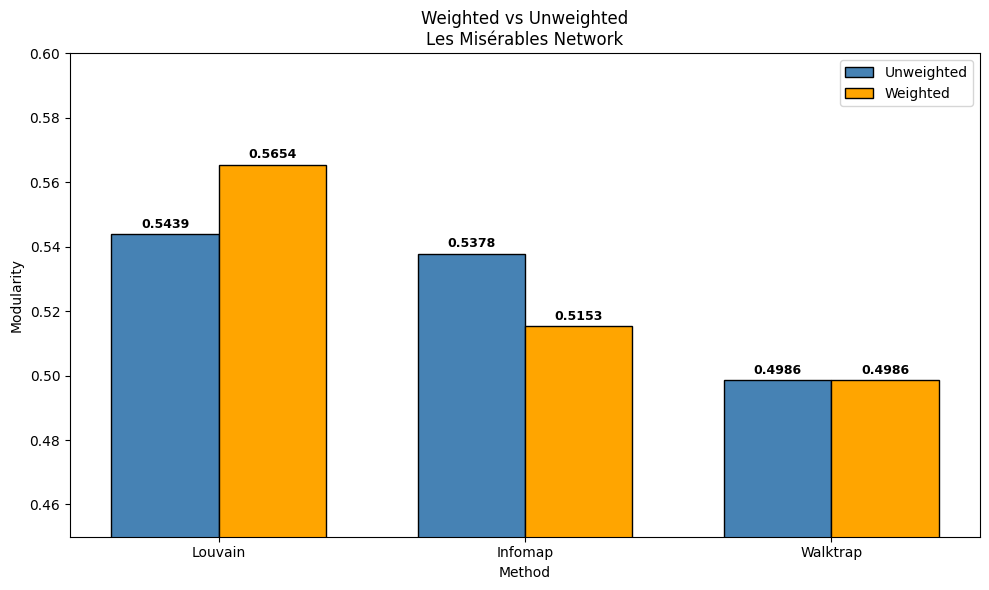

Figure 4.4c saved as 'figure_4_4c_les_miserables_modularity.png'


In [ ]:
methods = ["Louvain", "Infomap", "Walktrap"]
unweighted_modularity = [0.5439, 0.5378, 0.4986]
weighted_modularity = [0.5654, 0.5153, 0.4986]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, unweighted_modularity, width,
               label='Unweighted', color='steelblue', edgecolor="black")

bars2 = ax.bar(x + width/2, weighted_modularity, width,
               label='Weighted', color='orange', edgecolor="black")

ax.set_xlabel("Method")
ax.set_ylabel("Modularity")
ax.set_title("Weighted vs Unweighted\nLes Misérables Network")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.set_ylim(0.45, 0.60)

# add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center", fontsize=9, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig('figure_4_4c_les_miserables_modularity.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.4c saved as 'figure_4_4c_les_miserables_modularity.png'")
